<a href="https://colab.research.google.com/github/guigeof/TF/blob/main/simulacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Código Simulação 
# injeção salina em poços
Com base em:
Coupled hydrogeophysical modelling example. This essentially represents the
forward modelling step of the example presented in section 3.2 of the [pyGIMLi
paper](http://www.sciencedirect.com/science/article/pii/S0098300417300584/pdfft?md5=44253eaacd5490e3fb32210671672496&pid=1-s2.0-S0098300417300584-main.pdf).


In [6]:
# Checkout www.pygimli.org for more examples 
#!pip install pygimli tetgen 

```mermaid
flowchart TB
    classDef default font-size:55px width:300

    subgraph B1[Import Libraries]
        direction TB
        style B1 fill:#8c8,stroke:#888
        B1_1[import numpy as np]
        B1_2[import matplotlib.pyplot as plt]
        B1_3[import pygimli as pg]
        B1_4[import pygimli.meshtools as mt]
        B1_5[import pygimli.physics.ert as ert]
        B1_6[import pygimli.physics.petro as petro]
        B1_7[from pygimli.physics import ERTManager]
    end
    B --> B1

    subgraph C1[Define Parameters]
        direction TB
        style C1 fill:#8c8,stroke:#888
        C1_1[Define Spatial Parameters]
        C1_2[Define Hydraulic Parameters]
        C1_3[Define Temporal Parameters]
        C1_4[Calculate Relative Spatial Parameters]
        C1_5[Calculate Electrode Spacing]
        C1_6[Calculate Simulation Time]
    end
    C --> C1

    subgraph D1[Geometry Definition]
        direction TB
        style D1 fill:#8c8,stroke:#888
        D1_1[Create World Geometry]
        D1_2[Create Boreholes]
        D1_3[Combine Geometries]
    end
    D --> D1

    subgraph E1[Boundary Conditions]
        direction TB
        style E1 fill:#cc8,stroke:#888
        E1_1[Define Hydraulic Potential Boundary Conditions]
        E1_2[Define Boundary Markers for Boreholes]
        E1_3[Define Boundary Markers for Terrain]
    end
    E --> E1

    subgraph F1[Hydraulic Potential Model]
        direction TB
        style F1 fill:#8c8,stroke:#888
        F1_1[Map Conductivity Values]
        F1_2[Solve Finite Elements for Hydraulic Potential]
    end
    F --> F1

    subgraph G1[Calculate Velocity]
        direction TB
        style G1 fill:#8c8,stroke:#888
        G1_1[Calculate Gradient of Hydraulic Potential]
    end
    G --> G1

    subgraph H1[Saline Concentration]
        direction TB
        style H1 fill:#8c8,stroke:#888
        H1_1[Define Source Vector]
        H1_2[Calculate Saline Concentration for Each Cell]
    end
    H --> H1

    subgraph I1[ADV DISP Model]
        direction TB
        style I1 fill:#c99,stroke:#888
        I1_1[Calculate Dispersion]
        I1_2[Solve Finite Volume for Injection Time]
        I1_3[Solve Without Injection]
    end
    I --> I1

    subgraph J1[ERT Mesh Definition]
        direction TB
        style J1 fill:#8c8,stroke:#888
        J1_1[Create ERT Data]
        J1_2[Create ERT Mesh]
    end
    J --> J1

    subgraph K1[Archie's Law Application]
        direction TB
        style K1 fill:#c99,stroke:#888
        K1_1[Calculate Fluid Conductivity]
        K1_2[Calculate Bulk Resistivity]
        K1_3[Apply Background Resistivity Model]
    end
    K --> K1

    subgraph L1[ERT Simulation]
        direction TB
        style L1 fill:#8c8,stroke:#888
        L1_1[Simulate Apparent Resistivities]
        L1_2[Filter Negative Data Values]
        L1_3[Calculate Statistics for Apparent Resistivities]
    end
    L --> L1

    subgraph M1[Inversion and Visualization]
        direction TB
        style M1 fill:#cc8,stroke:#888
        M1_1[Create Data Container for Inversion]
        M1_2[Add Error Values]
        M1_3[Initialize ERTManager]
        M1_4[Invert Data]
    end
    M --> M1

    subgraph Passos
        style Passos stroke:#000,stroke-width:3px
        A[Início simulação] --> B[Import Libraries]
        B --> C[Define Parameters]
        C --> D[Geometry Definition]
        D --> E[Boundary Conditions]
        E --> F[Hydraulic Potential Model]
        F --> G[Calculate Velocity]
        G --> H[Saline Concentration]
        H --> I[ADV DISP Model]
        I --> J[ERT Mesh Definition]
        J --> K[Archie's Law Application]
        K --> L[ERT Simulation]
        L --> M[Inversion and Visualization]
    end

    click B call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L12")
    click C call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L22")
    click D call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L82")
    click E call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L122")
    click F call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L162")
    click G call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L202")
    click H call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L242")
    click I call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L282")
    click J call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L322")
    click K call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L362")
    click L call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L402")
    click M call linkCallback("c:/Users/guilh/Desktop/gimli/TF/Simu/3camadas_cell.ipynb#L442")

```

In [7]:
# Importar bibliotecas 

import numpy as np 
import matplotlib.pyplot as plt 
import pygimli as pg 
import pygimli.meshtools as mt 
import pygimli.physics.ert as ert 
import pygimli.physics.petro as petro 
from pygimli.physics import ERTManager 
#from numba import jit, cuda 
""" print_memory_usage():
    import os
    import psutil
    process = psutil.Process(os.getpid())
    print(f"Memory usage: {process.memory_info().rss / 1024 ** 2} MB") """

' print_memory_usage():\n    import os\n    import psutil\n    process = psutil.Process(os.getpid())\n    print(f"Memory usage: {process.memory_info().rss / 1024 ** 2} MB") '

In [8]:
### Parametros
## Espaciais
# Espaciais dos furos
pos_poco = [-20, -15, -10, -5, 0, 5, 10, 15]                       # Posição central dos furos
prof_poco=-1.9            # Profundidade dos furos
altura_poco= -0.1         # Altura dos furos
raio_poco= 0.175 + 0.3  #precisa ser decimal Ex:"3.00001"

# Espaciais do Terreno
box_esq=-40           # Limite esquerdo do terreno em metros
box_dir=40            # Limite direito do terreno em metros
box_top=0.01          # Limite superior do terreno em metros
box_bottom=-20        # Limite inferior do terreno em metros
L_mundo1 = -3   # Profundidade Layer mundo1
L_mundo2 = -10  # Profundidade Layer mundo2



# Espaciais discretização de células
mesh_area=0.4               # Área da mesh em metros^2
mesh_quality=20             # Qualidade da mesh. EVITAR valores acima de 33 por questões de limitações/performance

## Hidráulicos do meio
# Condutividade Hidráulica K em m/s 
K_poco = 1e3       # Poço
K_mundo1 = 1.4e1    # Latossolo
K_mundo2 = 1.8e1     # Latossolo seco 
K_mundo3 = 3.5e-2    # Rocha
K_frac = 1.2e3      # Fratura

""" K_poco = 1e3    #poço
K_mundo1 = 1.4e1    #latossolo
K_mundo2 = 1.2e1    #latossolo seco 
K_mundo3 = 3.5e1    #rocha """
# Marcador de região do modelo
Mk_poco = 0      # poço
Mk_mundo1 = 1    # latossolo    
Mk_mundo2 = 2    # fratura 
Mk_mundo3 = 3    # rocha

# Resumir Condutividades hidráulicas em uma variável só
kMap = [[Mk_mundo1, K_mundo1],  [Mk_poco, K_poco], [Mk_mundo2,K_mundo2],[Mk_mundo3,K_mundo3] ]   # Use [[RegionMarker, ConductivityValue], ...]

# Propriedades do meio poroso ADV/DISP
phi = 0.3                   # Porosidade meio
D = 0.9                    # Coeficiente de dispersão m^2/s


## Traçador                 


res_water = 10000            # Resistividade da água em Ohm.m 
# Condutividade elétrica da soulução definida pela simplificação linear(A+bx) para o NaCl da lei de Kohlrausch 
sigma_a = -0.00031          # sigma_a = 0.01           
sigma_bx = 0.19330          # sigma_bx = 0.1
TracerCon = 13.27           # Concentração do traçador em g/l
cementation_exponent = 1.1  # Exponente de cimentação para a resolução da resistividade do solo pela lei de Archie


# Resistividade do meio em Ohm.m
Layer0=box_top
RLayer0=300
Layer1=-2                    # Prof. da camada 1
RLayer1=150                  # Resistividade da camada 1
Layer2=-8                    # Prof. da camada 2
RLayer2=4464                 # Resistividade da camada 2
Layer3=-24                   # Prof. da camada 3
RLayer3=3300                 # Resistividade da camada 4

# Configuração ERT 
ERT_dist= 300               # Distância total dos eletrodos em m
ERT_elecs = 60               # Quantidade de eletrodos
ERT_spac = 5                # Espaçamento entre os eletrodos em m
ERT_Array = 'dd'             # wn, ws, wa, wb, dd, pd, pp, grad 
nLayers=20                   # Número de camadas para a simulação de ERT 

y_limit = 60                 # Corte gráfico dos dados profundos da simulação abaixo do dipolo y_limit 



# Temporais
TimeSimu_days = 4/24               # Tempo de simulação em dias  
TimeSimu_sec = TimeSimu_days*24*60*60   # Tempo de simulação em seg  
TimeSimu_steps = 24             # Quantidade de passos pra simulação
number_of_timesERT = 24         # Número de vezes que a simulação de ERT é executada


# Cálculos Espaciais relativos do furo
esq = '.' + f'{raio_poco:.2f}'.split('.')[1]
dir = '.' + f'{1 - raio_poco:.2f}'.split('.')[1]#print(f'raio_poco={raio_poco:.2f} esq={esq} dir={dir}')

# Cálculo Espaçamento dos eletrodos
elecs = pg.utils.grange(-ERT_dist/2, ERT_dist/2, ERT_elecs)

#Cálculo tempo de simulação
tlin = pg.utils.grange(start=0.1, end=TimeSimu_sec, n=TimeSimu_steps)
tlog = np.logspace(np.log10(0.1), np.log10(TimeSimu_sec), num=TimeSimu_steps)
t0 = pg.utils.grange(0,1000,n=TimeSimu_steps//2)
tn= pg.utils.grange(0,TimeSimu_sec,n=TimeSimu_sec/100)  #tempo grande pra estabilizar a simulação com Courrant Friederich's-Lewy (CFL)  
t=tlin #tlin #tlog #t0 #tn
#print(t)



## Definição da geometria do domínio da simulação 



In [9]:
# Criação da geometria de 3 camadas
world = mt.createWorld(start=[box_esq, box_top], end=[box_dir, box_bottom], WorldMarker=False, layers=[L_mundo1,L_mundo2]) 
# Criação dos furos de injeção
poco = []
for bor in pos_poco:
    poco.append(mt.createRectangle(start=[bor - raio_poco, altura_poco], end=[bor + raio_poco,prof_poco],marker=0)) #,isHole=True, boundaryMarker=3000))
# Combinar todos os furos em uma só variável
boreholes = poco[0]
for borehole in poco[1:]:
    boreholes = boreholes + borehole
# Definir marcadores para condições de contorno do poço
bores=poco[0]
for po in poco:
    for bd in po.boundaries():
        if bd.norm()[0] == 1:  # Right side
            bd.setMarker(2)
        elif bd.norm()[0] == -1: #Left side
            bd.setMarker(2)
        elif bd.norm()[1] == 1:  # Top side
            bd.setMarker(3)
        elif bd.norm()[1] == -1:  # Bottom side
            bd.setMarker(4)
        bores+=po
# Criação de uma família de fraturas
frac = mt.createRectangle(start=[6, -6], end=[18, -6.2], marker=7, area=0.01)
frac.rotate([0, 0, -0.95])
fracture = frac
for i in range(4):
    new_frac = mt.createRectangle(start=[6 + np.random.random(), -6 + np.random.random()], end=[18 + np.random.random(), -6.2 + np.random.random()], marker=7, area=0.01)
    new_frac.rotate([0, 0, -0.95 + np.random.uniform(0.01, 0.3)])
    fracture += new_frac
# Definir geometria final do modelo de simulação
geom = world + bores #+ fracture
#pg.show(mesh)

### Condições de Contorno/Fronteira

Duas são as fronteiras que este modelo pretende atender:
A influência gravitacional, e a influência do gradiente hidráulico dos poços de injeção
 $\rho g h$



 Para isso a fronteira da superfície,
 e da base do modelo é definida como uma fronteira de pressão constante (Dirichlet)
 Para os furos, o topo do poço assume a pressão variável com a altura (Neumann)

A pressão nos furos, apesar de ser variável, é calculada somente no tempo 0 como uma pressão constante. 

Alguma inconsistência ou a própia solução deixa a solução periódica. 

Para um modelo mais realista, fronteiras mais elaboradas são recomendadas.



\begin{split}c \frac{\partial u}{\partial t} & = \nabla\cdot(a \nabla u)
+ b u + f(\mathbf{r},t)~~|~~\Omega_{\text{Mesh}}\\
u & = h~~|~~\Gamma_{\text{Dirichlet}}\\
a\frac{\partial u}{\partial \mathbf{n}} & =
g~~|~~\Gamma_{\text{Neumann}}\\
\alpha u + \beta\frac{\partial u}{\partial \mathbf{n}} & =
\gamma~~|~~\Gamma_{\text{Robin}}\\
\frac{\partial u}{\partial \mathbf{n}} & =
\alpha(u_0-u)~~|~~\Gamma_{\text{Robin}}\end{split}

https://www.pygimli.org/pygimliapi/_generated/pygimli.solver.html#pygimli.solver.solveFiniteElements

{'Dirichlet': {-2: 0.0, -1: 1}}


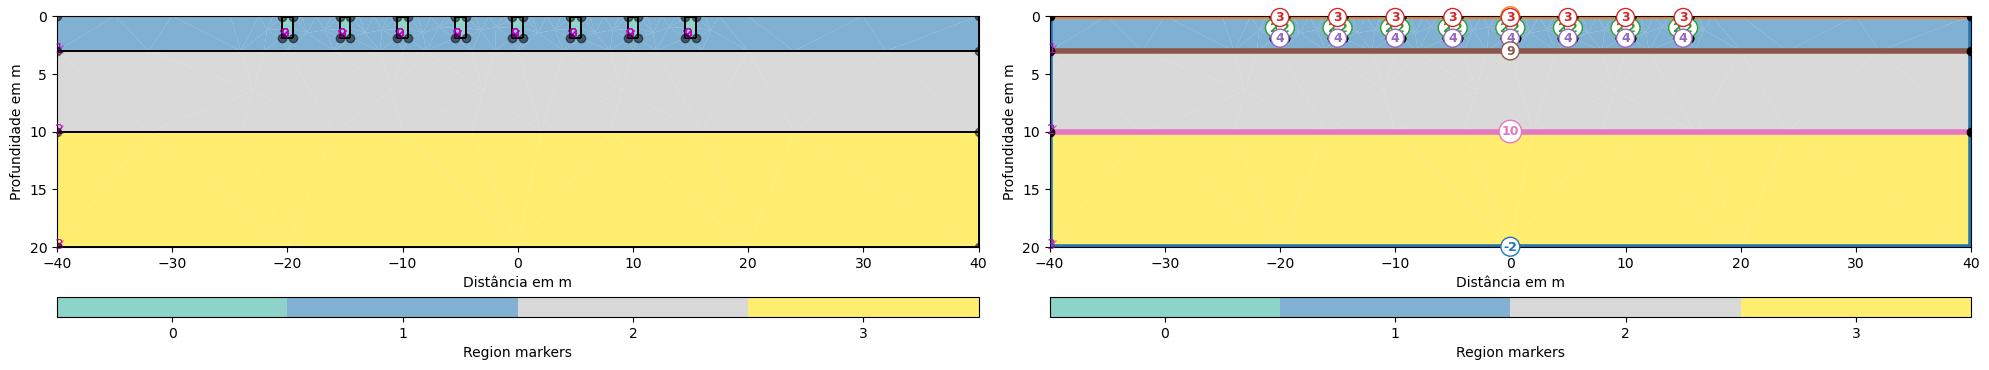

In [10]:
# FE EDP - Condições de Contorno - potencial hidráulico 
basemundo_2 = 0.0             # Definir valores de fronteira pro potencial hidráulico 
superficie_1= 1
# Fronteiras dos furos 
bocaBC=0
#lateraisBC= lambda boundary: (boundary.center()[1]-prof_poco) if boundary.center()[1] > 0 else -(prof_poco+boundary.center()[1])
fundoBC=-prof_poco
# Adequar as fronteiras para o problema de potencial hidráulico, com a numeração das bordas e unificar todas em um só dicionário
# Utilizar as condições da função na célula abaixo
dirichletBC = { -2: basemundo_2, -1: superficie_1,} # { , "Dirichlet": dirichletBC, }
neumannBC = { 4: fundoBC, } # { , "Neumann": neumannBC, } 
robinBC = {} # { , "Robin": robinBC, }
pBound = { "Dirichlet":dirichletBC} #{marker: value, ...}         # {Dirichlet, Neumann, Robin} 
print(pBound)
# Plot marcadores de fronteira do modelo
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
pg.show(geom, label='Marcadores de Regiões ', showNodes=True, markers=False, showMesh=False, ax=axs[0]) 
pg.show(geom, label='Marcadores de Fronteiras', showNodes=False, markers=True, showMesh=False, ax=axs[1]) 
axs[0].set_xlabel('Distância em m')
axs[0].set_ylabel('Profundidade em m')
axs[1].set_xlabel('Distância em m')
axs[1].set_ylabel('Profundidade em m')
plt.show()

## Lei de Darcy e Eq. Continuidade
Com a equação governante da lei de Darcy(1) e a equação da continuidade(5):
Cada célula terá seu valor de pressão e velocidade de fluxo, e a solução será realizada por Elementos Finitos(FE)


\begin{align}
\underbrace{\green{Q}=\green{A} \blue{\frac{-k}{\mu}} \red{\frac{\Delta p}{L}}}_{\text{Lei de Darcy}} , \quad {\green{\underbrace{\vec{v}=\frac{Q}{A}}_{\text{Veloci.}}}}, \quad{\blue{\underbrace{K=-\frac{k}{\mu}}_{\text{Cond. hidráulica}}}},\quad{\red{\underbrace{{\nabla p} = \frac{\Delta p}{L}}_{\text{Grad. hidráulico}}}},  
\\ \quad\underbrace{\nabla \cdot v = 0}_{\text{Continuidade}}, \quad \underbrace{{\vec{v}}={K}{\nabla p}}_{\text{Lei de Darcy}},   \\ 
   \text{Levando à}\quad
   \nabla\cdot(K \nabla p) = 0 \quad \text{em} \quad\Omega\end{align}







Para a solução a função simplificada pg.solver.solveFiniteElements(),



\begin{align}
c \frac{\partial u}{\partial t} & = \nabla\cdot(a \nabla u)+ b u + f(\mathbf{r},t)~~|~~\Omega_{\text{Malha}}\\
u & = h~~|~~\Gamma_{\text{Dirichlet}}\\
a\frac{\partial u}{\partial \mathbf{n}} & = g~~|~~\Gamma_{\text{Neumann}}\\
\alpha u + \beta\frac{\partial u}{\partial \mathbf{n}} & = \gamma~~|~~\Gamma_{\text{Robin}}\\
\frac{\partial u}{\partial \mathbf{n}} & =\alpha(u_0-u)~~|~~\Gamma_{\text{Robin}}
\end{align}


18/02/25 - 14:23:39 - pyGIMLi - WARNING - Unused arguments progress


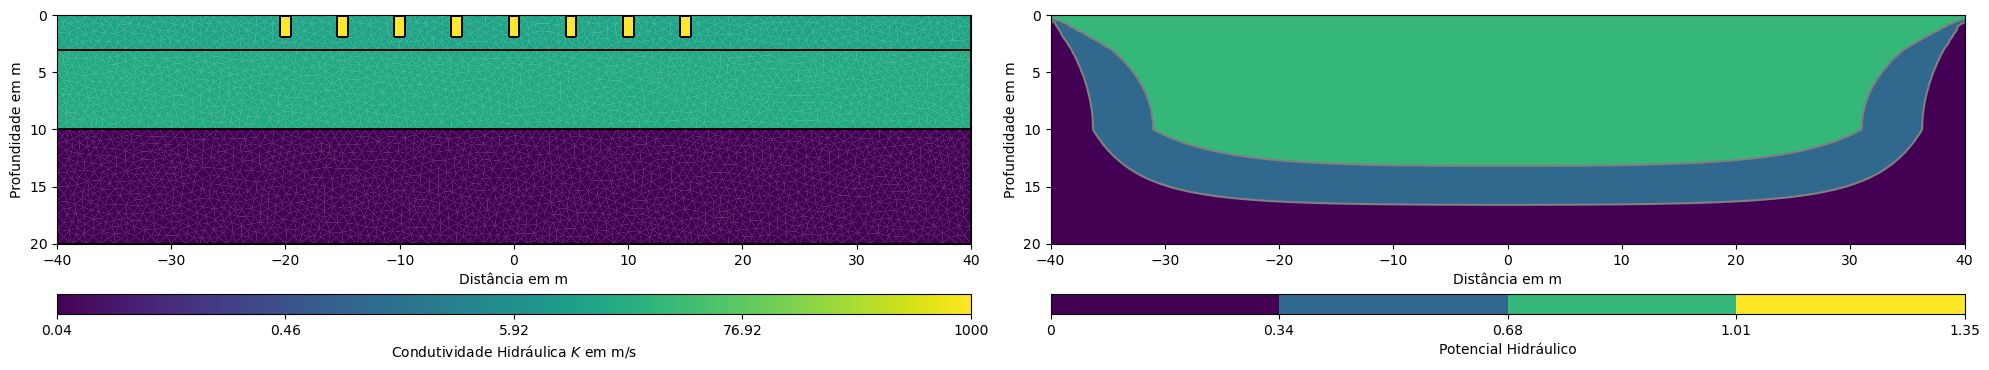

In [11]:
## Resolução de K por Darcy e Potencial por Elementos Finitos 
# Mapear valores da lista K para a célula da malha
mesh = mt.createMesh(geom, quality=mesh_quality, area=mesh_area, smooth=[1, 10])
K = pg.solver.parseMapToCellArray(kMap, mesh)
# Resolver o modelo de potencial hidráulico    '''Se p for estático, remover times=t, dynamic=True,''' Altura variável da água
p = pg.solver.solveFiniteElements(mesh, a=K, bc=pBound, progress=False)#stats=True) https://www.pygimli.org/_modules/pygimli/solver/solver.html#solveFiniteElements #p = np.random.rand(mesh.cellCount())   # Teste aleatorio
# Atualizar a visualização ou armazenar resultados
fig, axs = plt.subplots(1,2,figsize=(20, 20))
pg.show(mesh, data=K, label='Condutividade Hidráulica $K$ em m/s', cMap= 'viridis',logScale=True, ax=axs[0],orientation='horizontal')
pg.show(mesh, data=p, label='Potencial Hidráulico', cMap= 'viridis', cMin=np.min(p), cMax=np.max(p)+np.std(p), ax=axs[1],orientation='horizontal',
)
axs[0].set_xlabel('Distância em m')
axs[0].set_ylabel('Profundidade em m')
axs[1].set_xlabel('Distância em m')
axs[1].set_ylabel('Profundidade em m')
plt.show() 

## FE Velocidade
A velocidade hidráulica será calculada agora com os valores de potencial hidráulico $p$ adquiridos na interação anterior.

$\mathbf{v}=-\nabla p \space K$ 



Text(1011.6909722222218, 0.5, 'Profundidade em m')

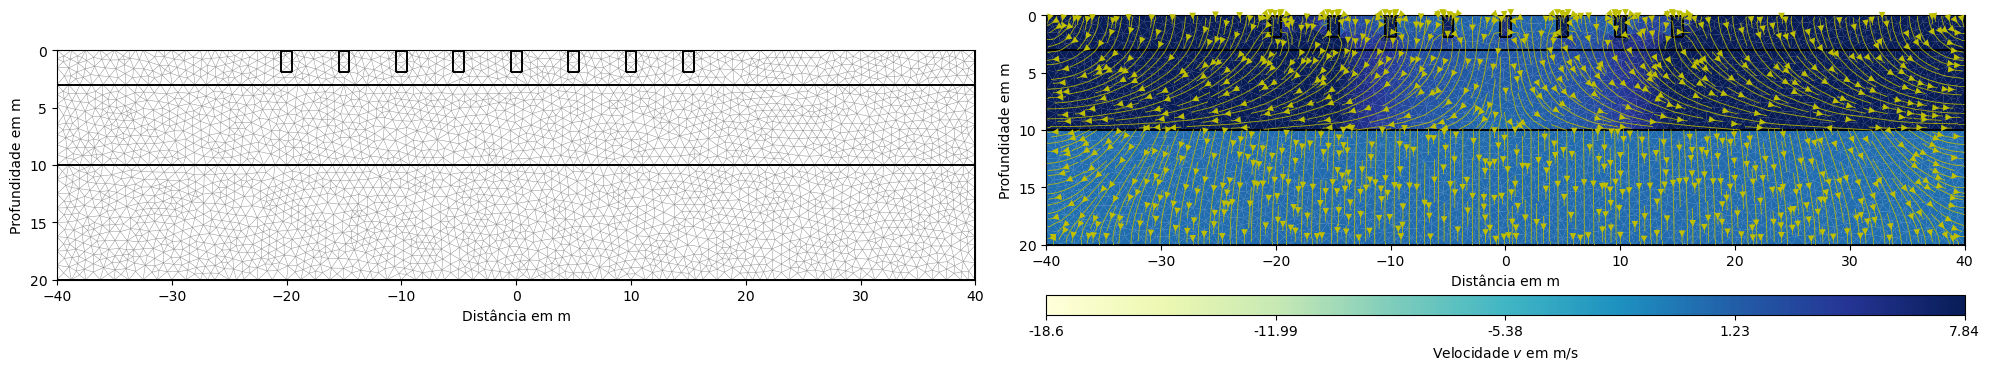

In [12]:
# Resolução da velocidade pelo gradiente do potencial hidráulico
vel=(-pg.solver.grad(mesh, p) * np.asarray([K, K, K]).T) 
    

fig, axs = plt.subplots(1,2,figsize=(20,10))
pg.show(mesh, data=pg.abs(vel)/1e-2, cMin=np.min(vel), cMax=np.max(vel),
                label='Velocidade $v$ em m/s', ax=axs[1], cMap='YlGnBu', hold=True,showStats=True)
pg.show(mesh, data=vel, color='y', linewidth=0.6, dropTol=1e-12, ax=axs[1])

pg.show(mesh, color='grey', linewidth=0.2, ax=axs[0],
                label='Malha de discretização ',axesxlabel='Distância em m',ylabel='Profundidade em m',) 

axs[0].set_xlabel('Distância em m')
axs[0].set_ylabel('Profundidade em m')
axs[1].set_xlabel('Distância em m')
axs[1].set_ylabel('Profundidade em m')

## Traçador
Definição dos pontos de entrada de solução salina e sua concentração

In [13]:
# Determinação da concentração salina por cada célula do poço
Source_vector = pg.Vector(mesh.cellCount(),0) #RVector
mm_stom_s=1e-3                  # Converter de mm/s para m/s
ltom3=1e-3                      # Converter de litros pra m^3
#prism=raio_poco*               # Área da seção transversal do poço se retangular
cil_ret=raio_poco*3.14/2        # Área da seção transversal do poço se cilíndrico
vol_extrd=cil_ret               # Volume do extrudado do poço
""" tempos dif S= chuva seca 
em época de chuva, S=periódico =pluviosidade e c0~=0.0001
em época de seca, S=periódico =evaporação/condensação ~-0.001
"""
for pos in pos_poco:
    for y in np.linspace(prof_poco+0.001 , altura_poco-0.001, num=300):
        sourceCelly = mesh.findCell([pos, y])
        if sourceCelly:
            if Source_vector[sourceCelly.id()]==0:
                Source_vector[sourceCelly.id()] = TracerCon*ltom3/ (sourceCelly.size()*vol_extrd)  # g/l *1e3 /m^3  #aproximação da concentração salina do poço
            for x in np.linspace(0.001+pos-raio_poco,pos+raio_poco-0.001,num=100):
                sourceCellx = mesh.findCell([x, y])
                Source_vector[sourceCellx.id()] = TracerCon *ltom3/ (sourceCellx.size()*vol_extrd)  # g/m^3


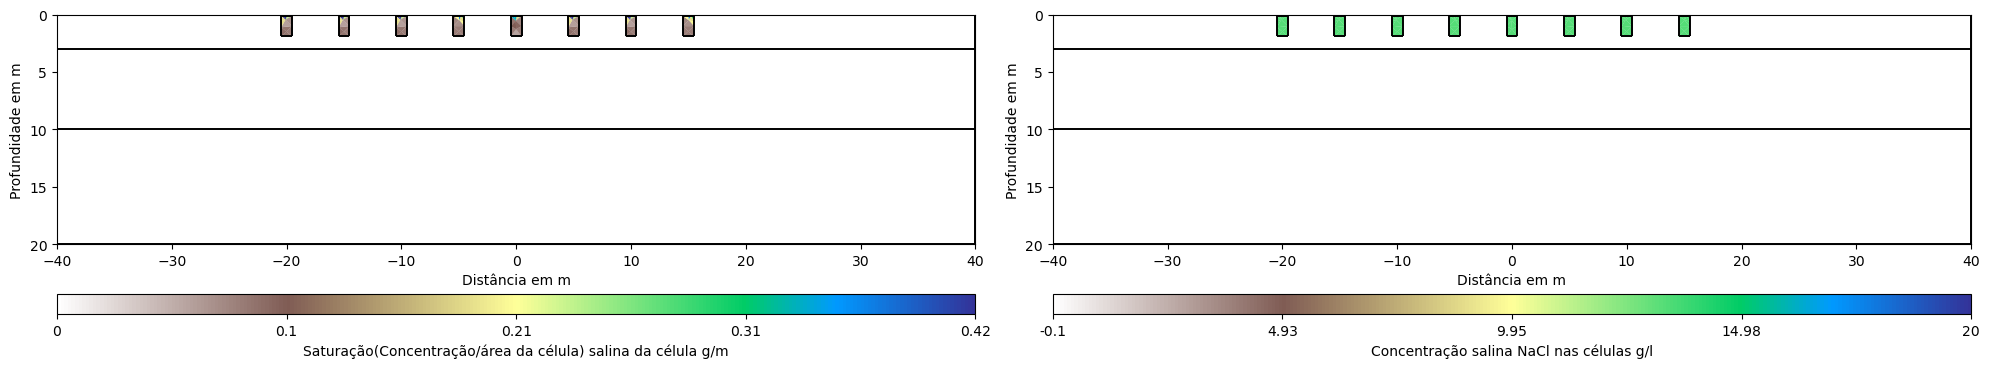

In [14]:
#Concentração Salina do poço no tempo inicial
fig, axs = plt.subplots(1,2,figsize=(20,10))
pg.show(mesh, data=Source_vector, label='Saturação(Concentração/área da célula) salina da célula g/m', ax=axs[0], cMap='terrain_r', hold=True,showStats=True)
pg.show(mesh, data=Source_vector/Source_vector*TracerCon, ax=axs[1], label='Concentração salina NaCl nas células g/l',cMap='terrain_r',cMax=20)
axs[0].set_xlabel('Distância em m')
axs[0].set_ylabel('Profundidade em m')
axs[1].set_xlabel('Distância em m')
axs[1].set_ylabel('Profundidade em m')
plt.show()

 $c(\mathbf{r}, t)$ in the aquifer
Utilizando a equação da advecção difusão, com os valores de velocidade, podemos calcular a distribuição espacial da concentração de sal em diferentes momentos do tempo.

\begin{align} 

 \frac{\partial c}{\partial t} =  {\color{Red} \underbrace{\nabla \cdot(D \nabla c)}_{\text{Difusão / Disperção}}} 
{\color{Blue} - \underbrace{\nabla \cdot(\mathbf{v}\nabla c)}_{\text{Advecção}}}    {\color{Green} + \text{Injeção inicial}}

\end{align}


\begin{split}

\frac{\partial u}{\partial t} & = {\color{Red} \nabla\cdot(a \nabla u)}{\color{Blue} \left [  -\mathbf{v}\cdot\nabla u  + b u  \right ]}{\color{Green} + f(\mathbf{r},t)}\\
u(\mathbf{r}, t) & = u_B  \quad\mathbf{r}\in\Gamma_{\text{Dirichlet}}\\
\frac{\partial u(\mathbf{r}, t)}{\partial \mathbf{n}} & = u_{\partial \text{B}}  \quad\mathbf{r}\in\Gamma_{\text{Neumann}}\\
u(\mathbf{r}, t=0) & = u_0 \quad\text{with} \quad\mathbf{r}\in\Omega

\end{split}



In [15]:
# Resolução do modelo de ADV DISP da concentração


# Velocities on cell nodes
veln = mt.cellDataToNodeData(mesh, vel)
raiodisp=1
#cone=1/3*3.14*(raio_poco**2+raiodisp**2+(raiodisp*raio_poco)) # vol cone de dispersão
""" vazio=0
for ti in range(0,1000):
    altura_movel = 0.000000003*ti**(2)-0.0017*ti+0.9
    if altura_movel==0:
        vazio=ti
        break
esvaziando=range(0,vazio)
continua=range(vazio, int(t[1])) """


#Create dispersitivity, depending on the absolute velocity
dispersion = pg.abs(vel) * mm_stom_s         #* float(cone)  # transform from mm/s to m/s
# Solve fo
#r injection time
S=(Source_vector)
Fn=(Source_vector)*(-0.1)   # (Source_vector)*(-0.1), 

""" (Source_vector)*(0.1)  """

c1 = pg.solver.solveFiniteVolume(mesh, a=dispersion,  f=S, fn=Fn,  vel=veln,times=t, scheme='PS', verbose=False) #fn=Fn

# Solve without injection starting with last result
c2 = pg.solver.solveFiniteVolume(mesh, a=dispersion, f=0, vel=veln, times=t, scheme='PS', verbose=False, u0=c1[-1])# u0 =timestep  u0=c1[-1],

# Stack results together
#c = np.vstack((c1, c2))
c=(c1)

# Calculate statistics
min_c_calc = 0.001 #mean_c - 1 * std_c
max_c_calc = 15 #mean_c + 2 * std_c
print(f"Mean: {np.mean(c)}, Std: {np.std(c)}, Min: {np.min(c)}, Max: {np.max(c)}")
#l=np.size(c,0)


18/02/25 - 14:24:02 - pyGIMLi - WARNING - Courant-Friedrichs-Lewy Number: 32759.24629348097 but should be lower 1 to ensure movement inside a cell per timestep. (vMax = 13.081039881354425 dt = 626.0826086956522 dx = 0.25 dt < 0.019111630441273047  | N >  32760 )
g:\0GG\gnv\00-code\Anaconda\envs\gimli\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
18/02/25 - 14:24:03 - pyGIMLi - WARNING - Courant-Friedrichs-Lewy Number: 32759.24629348097 but should be lower 1 to ensure movement inside a cell per timestep. (vMax = 13.081039881354425 dt = 626.0826086956522 dx = 0.25 dt < 0.019111630441273047  | N >  32760 )


Mean: 0.5048714626568418, Std: 0.5381843457951848, Min: -5.11554102365364e-13, Max: 6.076613257156943


Courant-Friedrichs-Lewy Number<1

The CFL condition is given by:

CFL = v_max * dt / dx


Reduce the time step size
Increase the spatial step size

0
1
2
3
4
5
6
7
8
9
10
11
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 9.70832896e-15  1.67731544e-02  2.77896982e-01 ... -4.25794765e-24
   1.25010910e-05  4.48714613e-05]
 [ 6.97254554e-15  1.16740193e-01  6.15848239e-01 ... -6.33550337e-24
   2.36341023e-04  7.62637771e-04]
 ...
 [ 2.52324842e-15  5.17178116e-01  5.17413313e-01 ... -5.70854086e-23
   5.80626486e-01  5.96548140e-01]
 [ 1.17395333e-15  5.17285255e-01  5.03471234e-01 ... -5.91673645e-23
   5.80603654e-01  5.96513325e-01]
 [-1.61858720e-15  5.17189766e-01  5.18849301e-01 ... -6.23464994e-23
   5.80573146e-01  5.96580131e-01]]


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x1d9c1ee7010>)

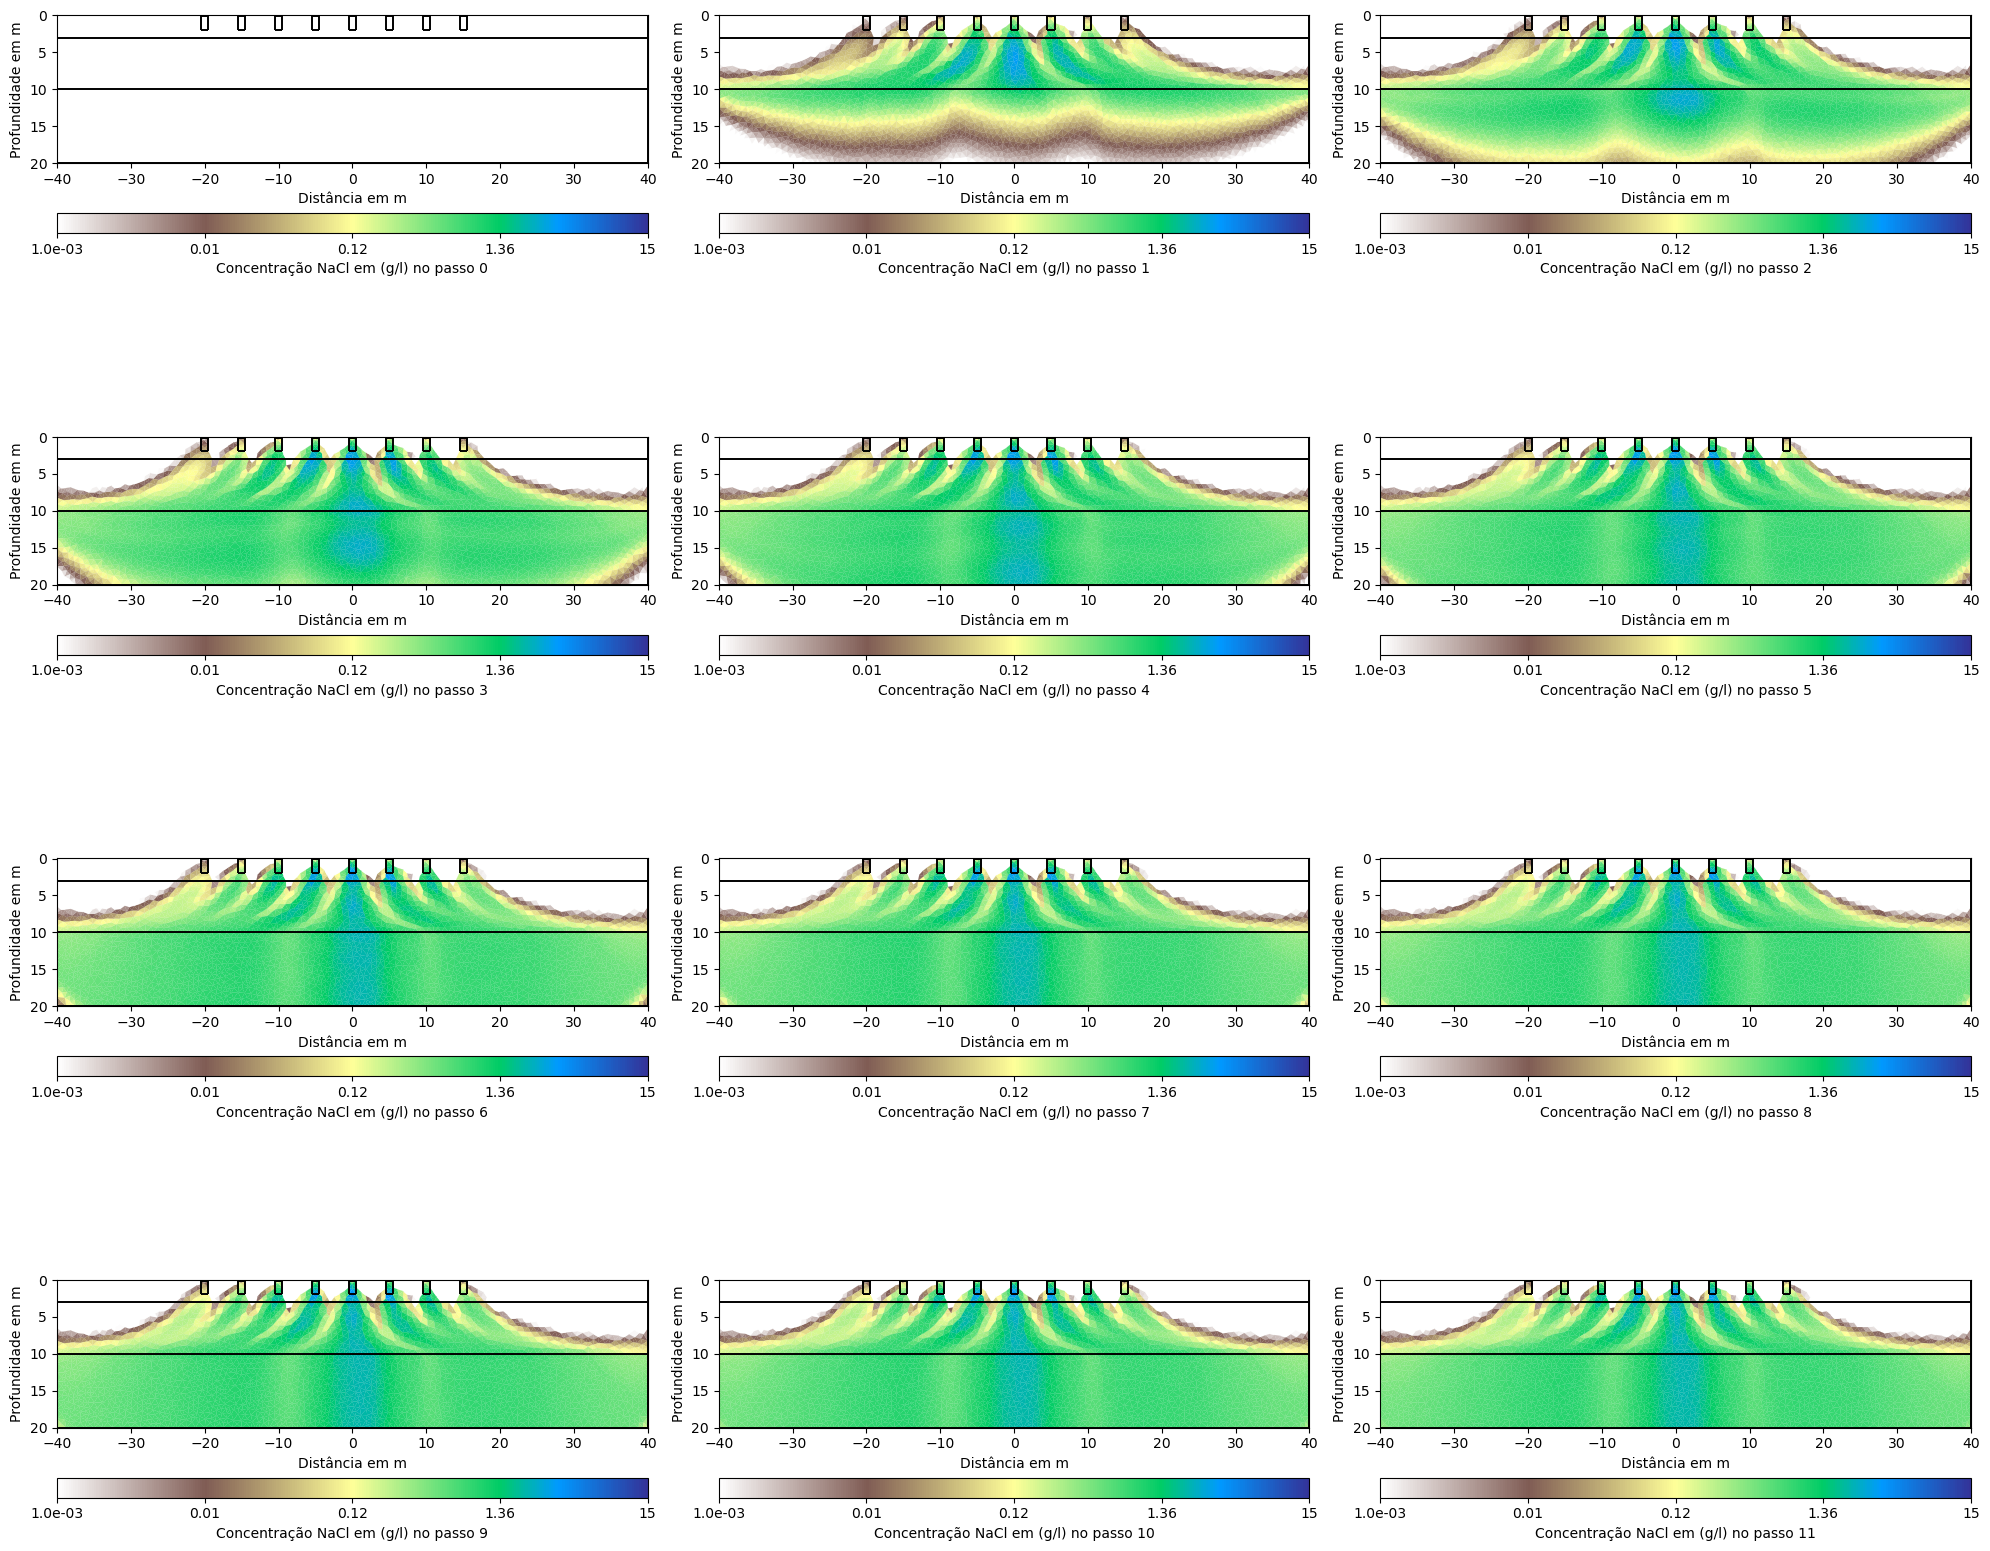

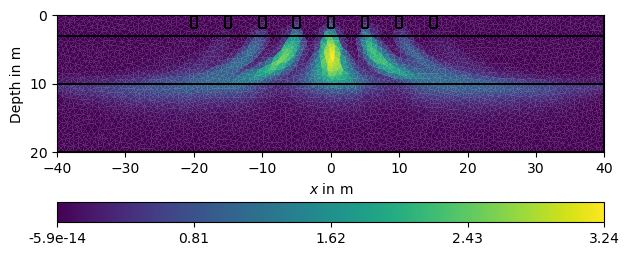

In [16]:
# Visualização da dispersão da concentração no tempo tfig, ax = plt.subplots(row, col, figsize=(20, 20),)

njumps=2
sec=int(TimeSimu_sec)
Time_Jumps=int(sec//TimeSimu_steps)
col=3
row=((TimeSimu_steps+2)//col)//njumps

# i=0
# fig, ax = plt.subplots(row, col, figsize=(20, 20),)
# for ci1 in c1[1:][::]: # jump x steps of Timesteps
#         print(i)
#         pg.show(mesh, data=ci1, cMin=min_c_calc, cMap="terrain_r", logScale=True,label=f"Concentração NaCl em (g/l) no passo {i}", orientation='horizontal', ax=ax[i // 3, i % 3],sharex=True,sharey=True)
#         i += 1

# i=0
# fig, ax = plt.subplots(row, col, figsize=(20, 20),)
# for ci2 in c2[1:][::]: # jump x steps of Timesteps cMax=max_c_calc,
#         print(i)
#         pg.show(mesh, data=ci2, cMin=min_c_calc, cMap="terrain_r", logScale=True,label=f"Concentração NaCl em (g/l) no passo {i}", orientation='horizontal', ax=ax[i // 3, i % 3],sharex=True,sharey=True)
#         i += 1

i = 0
fig, ax = plt.subplots(row, col, figsize=(20, 20),)
for ci in c[0:][::njumps]: #jump n steps of Timesteps
        print(i)
        pg.show(mesh, data=ci, cMin=min_c_calc, cMax=max_c_calc, cMap="terrain_r", logScale=True,label=f"Concentração NaCl em (g/l) no passo {i}", orientation='horizontal', ax=ax[i // 3, i % 3],sharex=True,sharey=True)
        ax[i // 3, i % 3].set_xlabel('Distância em m')
        ax[i // 3, i % 3].set_ylabel('Profundidade em m')
        i += 1




# for ci1, ci2, ci in zip(c1[1:][::], c2[1:][::], c[1:][::2]):
#     print(i)
#     pg.show(mesh, data=ci1, cMin=min_c_calc, cMap="terrain_r", logScale=True,label=f"Concentração NaCl em (g/l) no passo {i}", orientation='horizontal', ax=ax[i // 3, i % 3],sharex=True,sharey=True)
#     pg.show(mesh, data=ci2, cMin=min_c_calc, cMap="terrain_r", logScale=True,label=f"Concentração NaCl em (g/l) no passo {i}", orientation='horizontal', ax=ax[i // 3, i % 3],sharex=True,sharey=True)
#     pg.show(mesh, data=ci, cMin=min_c_calc, cMax=max_c_calc, cMap="terrain_r", logScale=True,label=f"Concentração NaCl em (g/l) no passo {i}", orientation='horizontal', ax=ax[i // 3, i % 3],sharex=True,sharey=True)
#     i += 1

print(c)
pg.show(mesh=mesh,data=c[2])

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

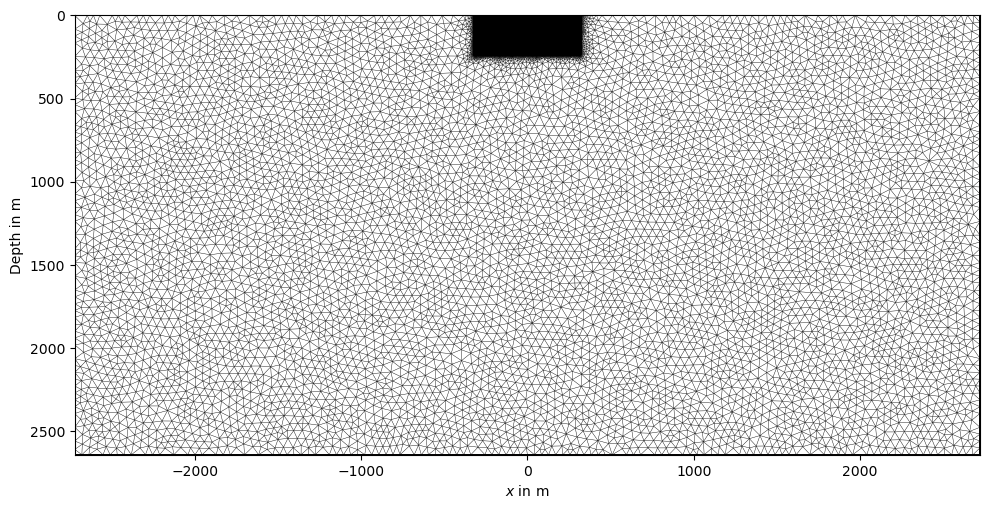

In [17]:
# ERT definição de malha de interação

#ertScheme = ert.createData(elecs=elecs, schemeName=ERT_Array)
ertScheme = ert.createData(pg.utils.grange(-300, 300, dx=10.0), schemeName=ERT_Array)
meshERT = mt.createParaMesh(ertScheme, nLayers=nLayers,quality=30, paraMaxCellSize=ERT_spac/8, boundaryMaxCellSize=1750, smooth=[1, 2], ) #manter n ParamaxCellSize menor que ERT_spac  ERT_spac/10
# Tempo de processamento
# 30 2 750 1 2 ==3.1s
# 30 1 750 1 2 ==5.1s
# 30 0.6 750 1 2 ==22.1s
# 30 0.6 1500 1 2 ==57.3s
pg.show(meshERT,Title='Mesh de cálculos ERT',figsize=(10,10))

## Lei de Archie

$$\underbrace{R_f}_{{\text{r\space fl}}} =\frac{1}{T}\underbrace{R_w}_{\text{água}}
{ \underbrace{\phi}_{{\text{Poros.}}}}^{\widehat{-m}^{\text{Cimentação}}}
{ \underbrace{S_w}_{{\text{Sat.}}}}^{\widehat{-n}^{\text{e sat}}}$$

$$\rho_{\text{r\space fl}} = a\rho_{\text{w}}\phi^{-m} S^{-n}$$

m - Cementation exponent of the rock (usually in the range 1.3 – 2.5 for sandstones)
n - is the saturation exponent (usually close to 2)

In [18]:

# Simulação elétrica por tempo, concentração para condutividade pela Lei de Archie
timesERT = pg.IVector(np.floor(np.linspace(0, len(c) - 1, number_of_timesERT)).astype(int)) # Select 10 time frame to simulate ERT data

# Condutividade do fluido para concentração salina
sigmaFluid = c[timesERT] * sigma_bx + sigma_a #sigmaFluid = c[timesERT] * 0.1 + 0.01
#https://www.pygimli.org/pygimliapi/_generated/pygimli.physics.petro.html

# Cálculo da Resistividade por 1/sigmaFluid
resBulk = petro.resistivityArchie(rFluid = 1/ sigmaFluid, porosity = phi, m=cementation_exponent, mesh=mesh, meshI=meshERT, fill=1)

# Aplicar resistividade de fundo ao modelo
rho0 = np.zeros(meshERT.cellCount())+1000    #np.random.rand()
resis = pg.Matrix(resBulk)
for cell in meshERT.cells():
    if cell.center()[1] < Layer3:
        rho0[cell.id()] = RLayer3
    elif cell.center()[1] < Layer2:
        rho0[cell.id()] = RLayer2
    elif cell.center()[1] < Layer1:
        rho0[cell.id()] = RLayer1

for i, rb in enumerate(resis):
    resis[i] = 1. / ((1. / rb) + 1. / rho0)
    #print(rb)




In [19]:
# Visualização 
import pandas as pd
matrix=pd.DataFrame(resis)

# Trocar números negativos de resistividade por zero
matrix = matrix.applymap(lambda x: x if x > 0 else None) #np.nan


print(matrix)
for i in range(len(resis)):
    mean_resis = np.mean(resis[i])
    std_resis = np.std(resis[i])
    min_resis = np.min(resis[i])
    max_resis = np.max(resis[i])
    print(f"Timestep {i}:")
    print(f"Mean: {mean_resis}, Std: {std_resis}, Min: {min_resis}, Max: {max_resis},")
    print(f"Matrix Timestep {i+1}:, Min:{np.min(matrix[i])}")
    print()
matrix = np.array(matrix)

         0           1            2            3            4       \
0   4533.513579  151.878375  4533.513579  4533.513579  4533.513579   
1   4440.771617   25.104630  4462.828444  4440.771617  4533.509074   
2   3589.715169   34.832900  3519.861396  3589.715169  4533.393460   
3   1317.399084   38.551621  1401.051856  1317.399084  4531.966101   
4    344.106461   27.539046   371.308336   344.106461  4520.552009   
5    109.028796   43.296850   116.564410   109.028796  4448.516436   
6     46.812129   27.199671    49.199401    46.812129  3856.752751   
7     27.312809   40.965364    28.082218    27.312809    90.897994   
8     21.286362   28.974219    21.360104    21.286362  2443.601469   
9     21.042977   37.280210    20.755125    21.042977  3273.736670   
10    23.139727   31.380840    22.913438    23.139727  1661.313035   
11    23.927814   34.340483    23.988187    23.927814   852.024941   
12    22.910745   33.549913    22.926120    22.910745   458.714427   
13    22.583393   32

In [20]:
# Simulação resistividade Aparente

# Definir variável ERT 
ERT = ERTManager(verbose=True)
# Simulação para resistividade aparente
rhoa = ERT.simulate(meshERT, res=matrix, scheme=ertScheme, returnArray=True, verbose=False,) # noiseLevel=1e-2, noiseAbs=1e-6,)
print('Simulated rhoa', rhoa, np.max(rhoa))
#rhoa.save('simple.dat')  # Salvar o arquivo
# Estatísticas
#Min_calcERT=mean_rhoa-2*std_rhoa,   Max_calcERT=mean_rhoa+2*std_rhoa,   cMin=1e-4,   cMax=1
#ERT.showData(ertScheme, vals=rhoa[2],LogScale=True) #tempScheme  cMin=Min_calcERT,cMax=Max_calcERT,

Simulated rhoa [[ 231.67627207  229.98854058  228.57428818 ... 2240.48063388
  2299.63704768 2176.44038258]
 [ 231.78958148  230.08041757  228.65942791 ... 2079.78653041
  2140.53386644 2031.49984173]
 [ 232.73175019  230.71368823  229.13377129 ... 2198.60328021
  2250.79166952 2155.77709629]
 ...
 [ 264.27450564  248.52813376  241.05130842 ...  143.92613685
   144.25734498  147.19915038]
 [ 264.27887636  248.53088561  241.05347159 ...  138.81861416
   139.13756666  141.98406907]
 [ 264.27975916  248.53184168  241.05445481 ...  135.16981399
   135.48509008  138.26449305]] nan


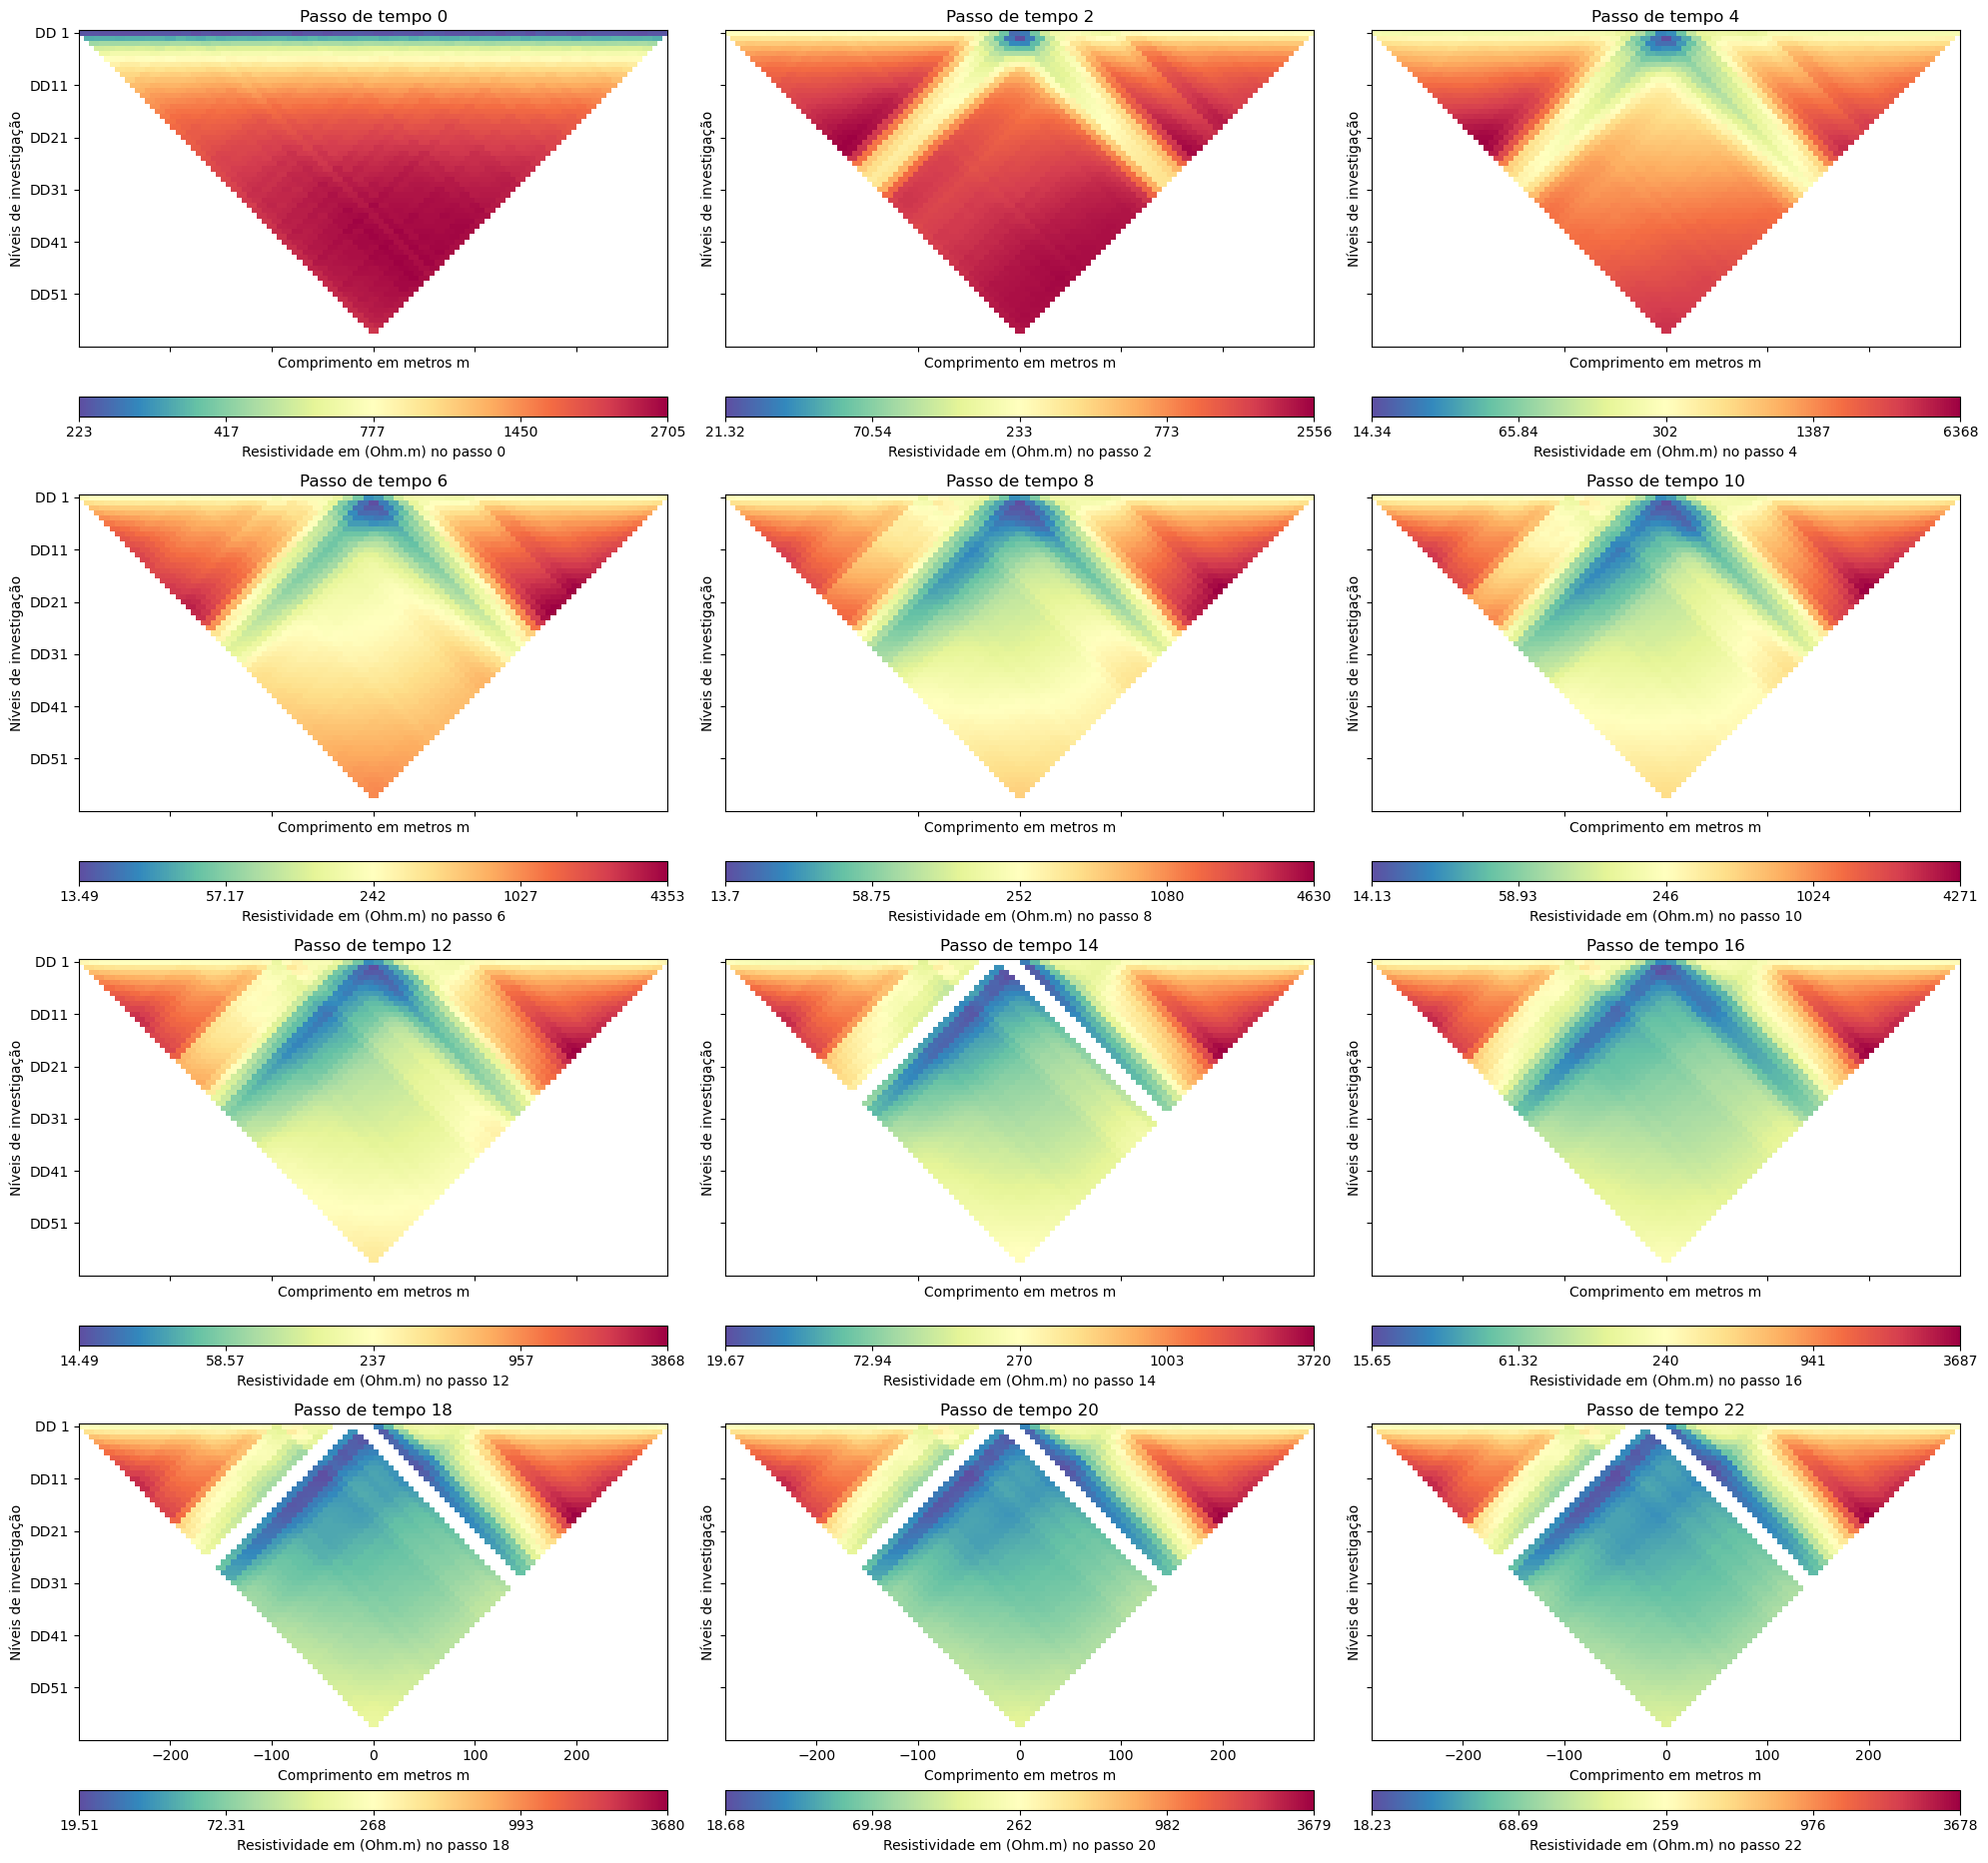

In [21]:
# Visualização Resistividade aparente sem processamento
col=3
row=(number_of_timesERT+2)//col//njumps
fig, axs = plt.subplots(row, col, figsize=(20, 15*((4+1)/(2*njumps))), sharex=True, sharey=True)
for i in range(len(rhoa)):
    
    # Cria cópia para cada passo de tempo
    tempScheme = ertScheme.copy()
    tempScheme.set('rhoa', rhoa[i])
    # Estatísticas
    mean_rhoa = np.mean(rhoa[i])
    std_rhoa = np.std(rhoa[i]) 
    min_rhoa = np.min(rhoa[i])    
    max_rhoa = np.max(rhoa[i])   
    Min_calcERT = min_rhoa   
    Max_calcERT = max_rhoa
    # print(f"Timestep {i}:"),    print(f"Mean: {mean_rhoa}, Std: {std_rhoa}, Min: {min_rhoa}, Max: {max_rhoa}, Min_calcERT: {Min_calcERT}, Max_calcERT: {Max_calcERT},"),    print()
    # Visualização dos dados
    if i % njumps==0:
        j=i//njumps
        ax=axs[ j// 3, j % 3]
        ax, _ = ERT.showData(tempScheme, vals=rhoa[i],LogScale=False,label=f"Resistividade em (Ohm.m) no passo {i}",ax=ax)
        ax.set_ylim(y_limit, ax.get_ylim()[1])  # Definir limite de corte para visualização dos dados profundos cMin=Min_calcERT,cMax=Max_calcERT,
        # Títulos e eixos
        ax.set_title(f'Passo de tempo {i}')
        ax.set_xlabel('Comprimento em metros m')
        ax.set_ylabel('Níveis de investigação') 
plt.tight_layout()
plt.show() 

Timestep 1:
Mean: 1654.923118401519, Std: 736.4318826296394, Min: 223.32435314390796, Max: 2704.8415777892455, Min_calcERT: 223.32435314390796, Max_calcERT: 2704.8415777892455,

Timestep 2:
Mean: 1218.7451149367919, Std: 665.3260353532005, Min: 25.134116787076078, Max: 2439.5980849309753, Min_calcERT: 25.134116787076078, Max_calcERT: 2439.5980849309753,

Timestep 3:
Mean: 1150.8905824292588, Std: 678.0642108411577, Min: 21.317186414338902, Max: 2556.4282918382337, Min_calcERT: 21.317186414338902, Max_calcERT: 2556.4282918382337,

Timestep 4:
Mean: 1373.3532259807218, Std: 993.2098764598317, Min: 18.125404504787024, Max: 4319.140692776545, Min_calcERT: 18.125404504787024, Max_calcERT: 4319.140692776545,

Timestep 5:
Mean: 1261.7941098258248, Std: 1044.2998956816948, Min: 14.344415402497347, Max: 6367.547118384616, Min_calcERT: 14.344415402497347, Max_calcERT: 6367.547118384616,

Timestep 6:
Mean: 886.4565943164503, Std: 795.5787715630976, Min: 15.542385659494146, Max: 4892.824036910225,

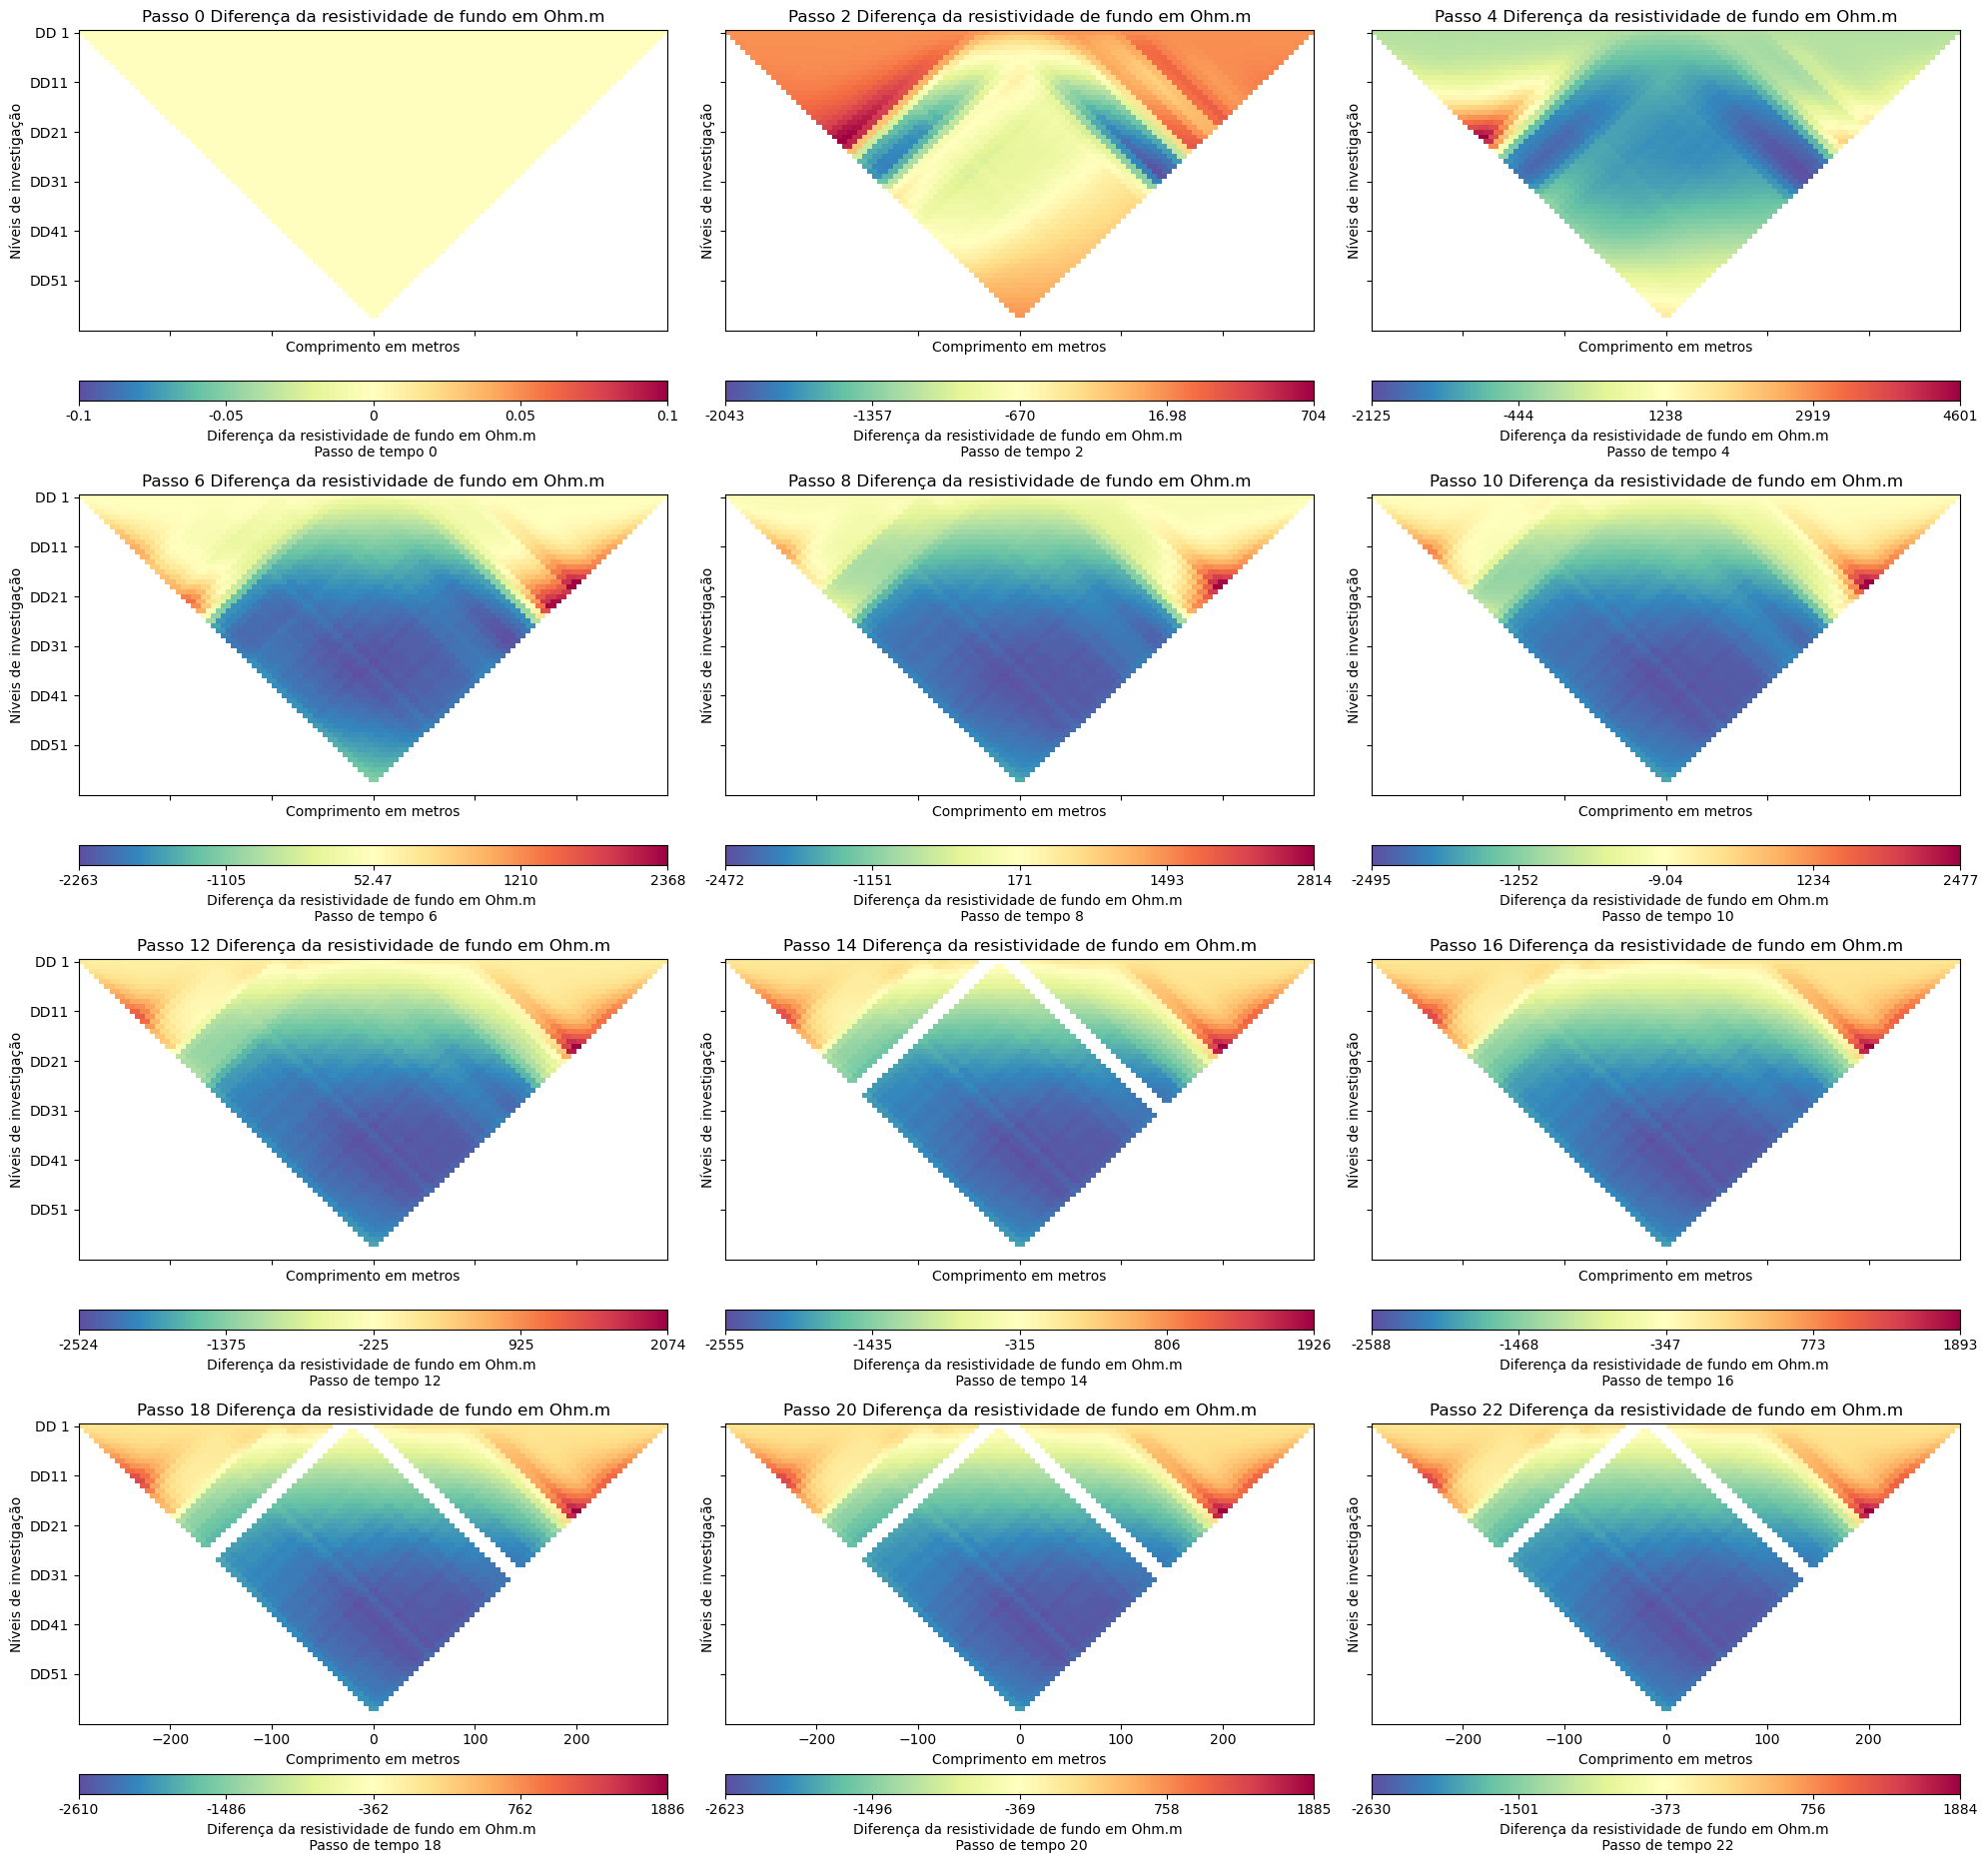

In [22]:
# #Visualização Subtração do Background
fig, axs = plt.subplots(row, col, figsize=(20, 15*((4+1)/(2*njumps))), sharex=True, sharey=True)
for i in range(len(rhoa)):
    
    tempScheme = ertScheme.copy()
    tempScheme.set('rhoa', rhoa[i])
    mean_rhoa = np.mean(rhoa[i])
    std_rhoa = np.std(rhoa[i])
    min_rhoa = np.min(rhoa[i])
    max_rhoa = np.max(rhoa[i])
    Min_calcERT=min_rhoa
    Max_calcERT=max_rhoa
    print(f"Timestep {i+1}:")
    print(f"Mean: {mean_rhoa}, Std: {std_rhoa}, Min: {min_rhoa}, Max: {max_rhoa}, Min_calcERT: {Min_calcERT}, Max_calcERT: {Max_calcERT},")
    print()
    if i % njumps==0:
        j=i//njumps
        ax=axs[ j// 3, j % 3]
        ax, _ = ERT.showData(tempScheme, vals=rhoa[i]-rhoa[0],LogScale=False,label=f"Diferença da resistividade de fundo em Ohm.m \n Passo de tempo {i}",ax=ax) # Subtração
        ax.set_ylim(y_limit, ax.get_ylim()[1])  
        ax.set_title(f'Passo {i} Diferença da resistividade de fundo em Ohm.m'),
        ax.set_xlabel('Comprimento em metros') 
        ax.set_ylabel('Níveis de investigação') 
plt.tight_layout()
plt.show()

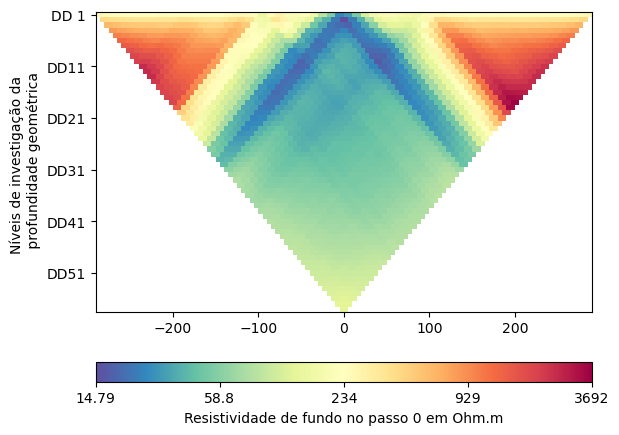

In [23]:
ERT.showData(tempScheme, vals=rhoa[23],LogScale=True,label=f"Resistividade de fundo no passo {0} em Ohm.m",ylabel='Níveis de investigação da \n profundidade geométrica')
plt.show()

Timestep 0:
Mean: 1654.923118401519, Std: 736.4318826296394, Min: 223.32435314390796, Max: 2704.8415777892455, Min_calcERT: 223.32435314390796, Max_calcERT: 2704.8415777892455,

Timestep 1:
Mean: 1218.7451149367919, Std: 665.3260353532005, Min: 25.134116787076078, Max: 2439.5980849309753, Min_calcERT: 25.134116787076078, Max_calcERT: 2439.5980849309753,

Timestep 2:
Mean: 1150.8905824292588, Std: 678.0642108411577, Min: 21.317186414338902, Max: 2556.4282918382337, Min_calcERT: 21.317186414338902, Max_calcERT: 2556.4282918382337,

Timestep 3:
Mean: 1373.3532259807218, Std: 993.2098764598317, Min: 18.125404504787024, Max: 4319.140692776545, Min_calcERT: 18.125404504787024, Max_calcERT: 4319.140692776545,

Timestep 4:
Mean: 1261.7941098258248, Std: 1044.2998956816948, Min: 14.344415402497347, Max: 6367.547118384616, Min_calcERT: 14.344415402497347, Max_calcERT: 6367.547118384616,

Timestep 5:
Mean: 886.4565943164503, Std: 795.5787715630976, Min: 15.542385659494146, Max: 4892.824036910225,

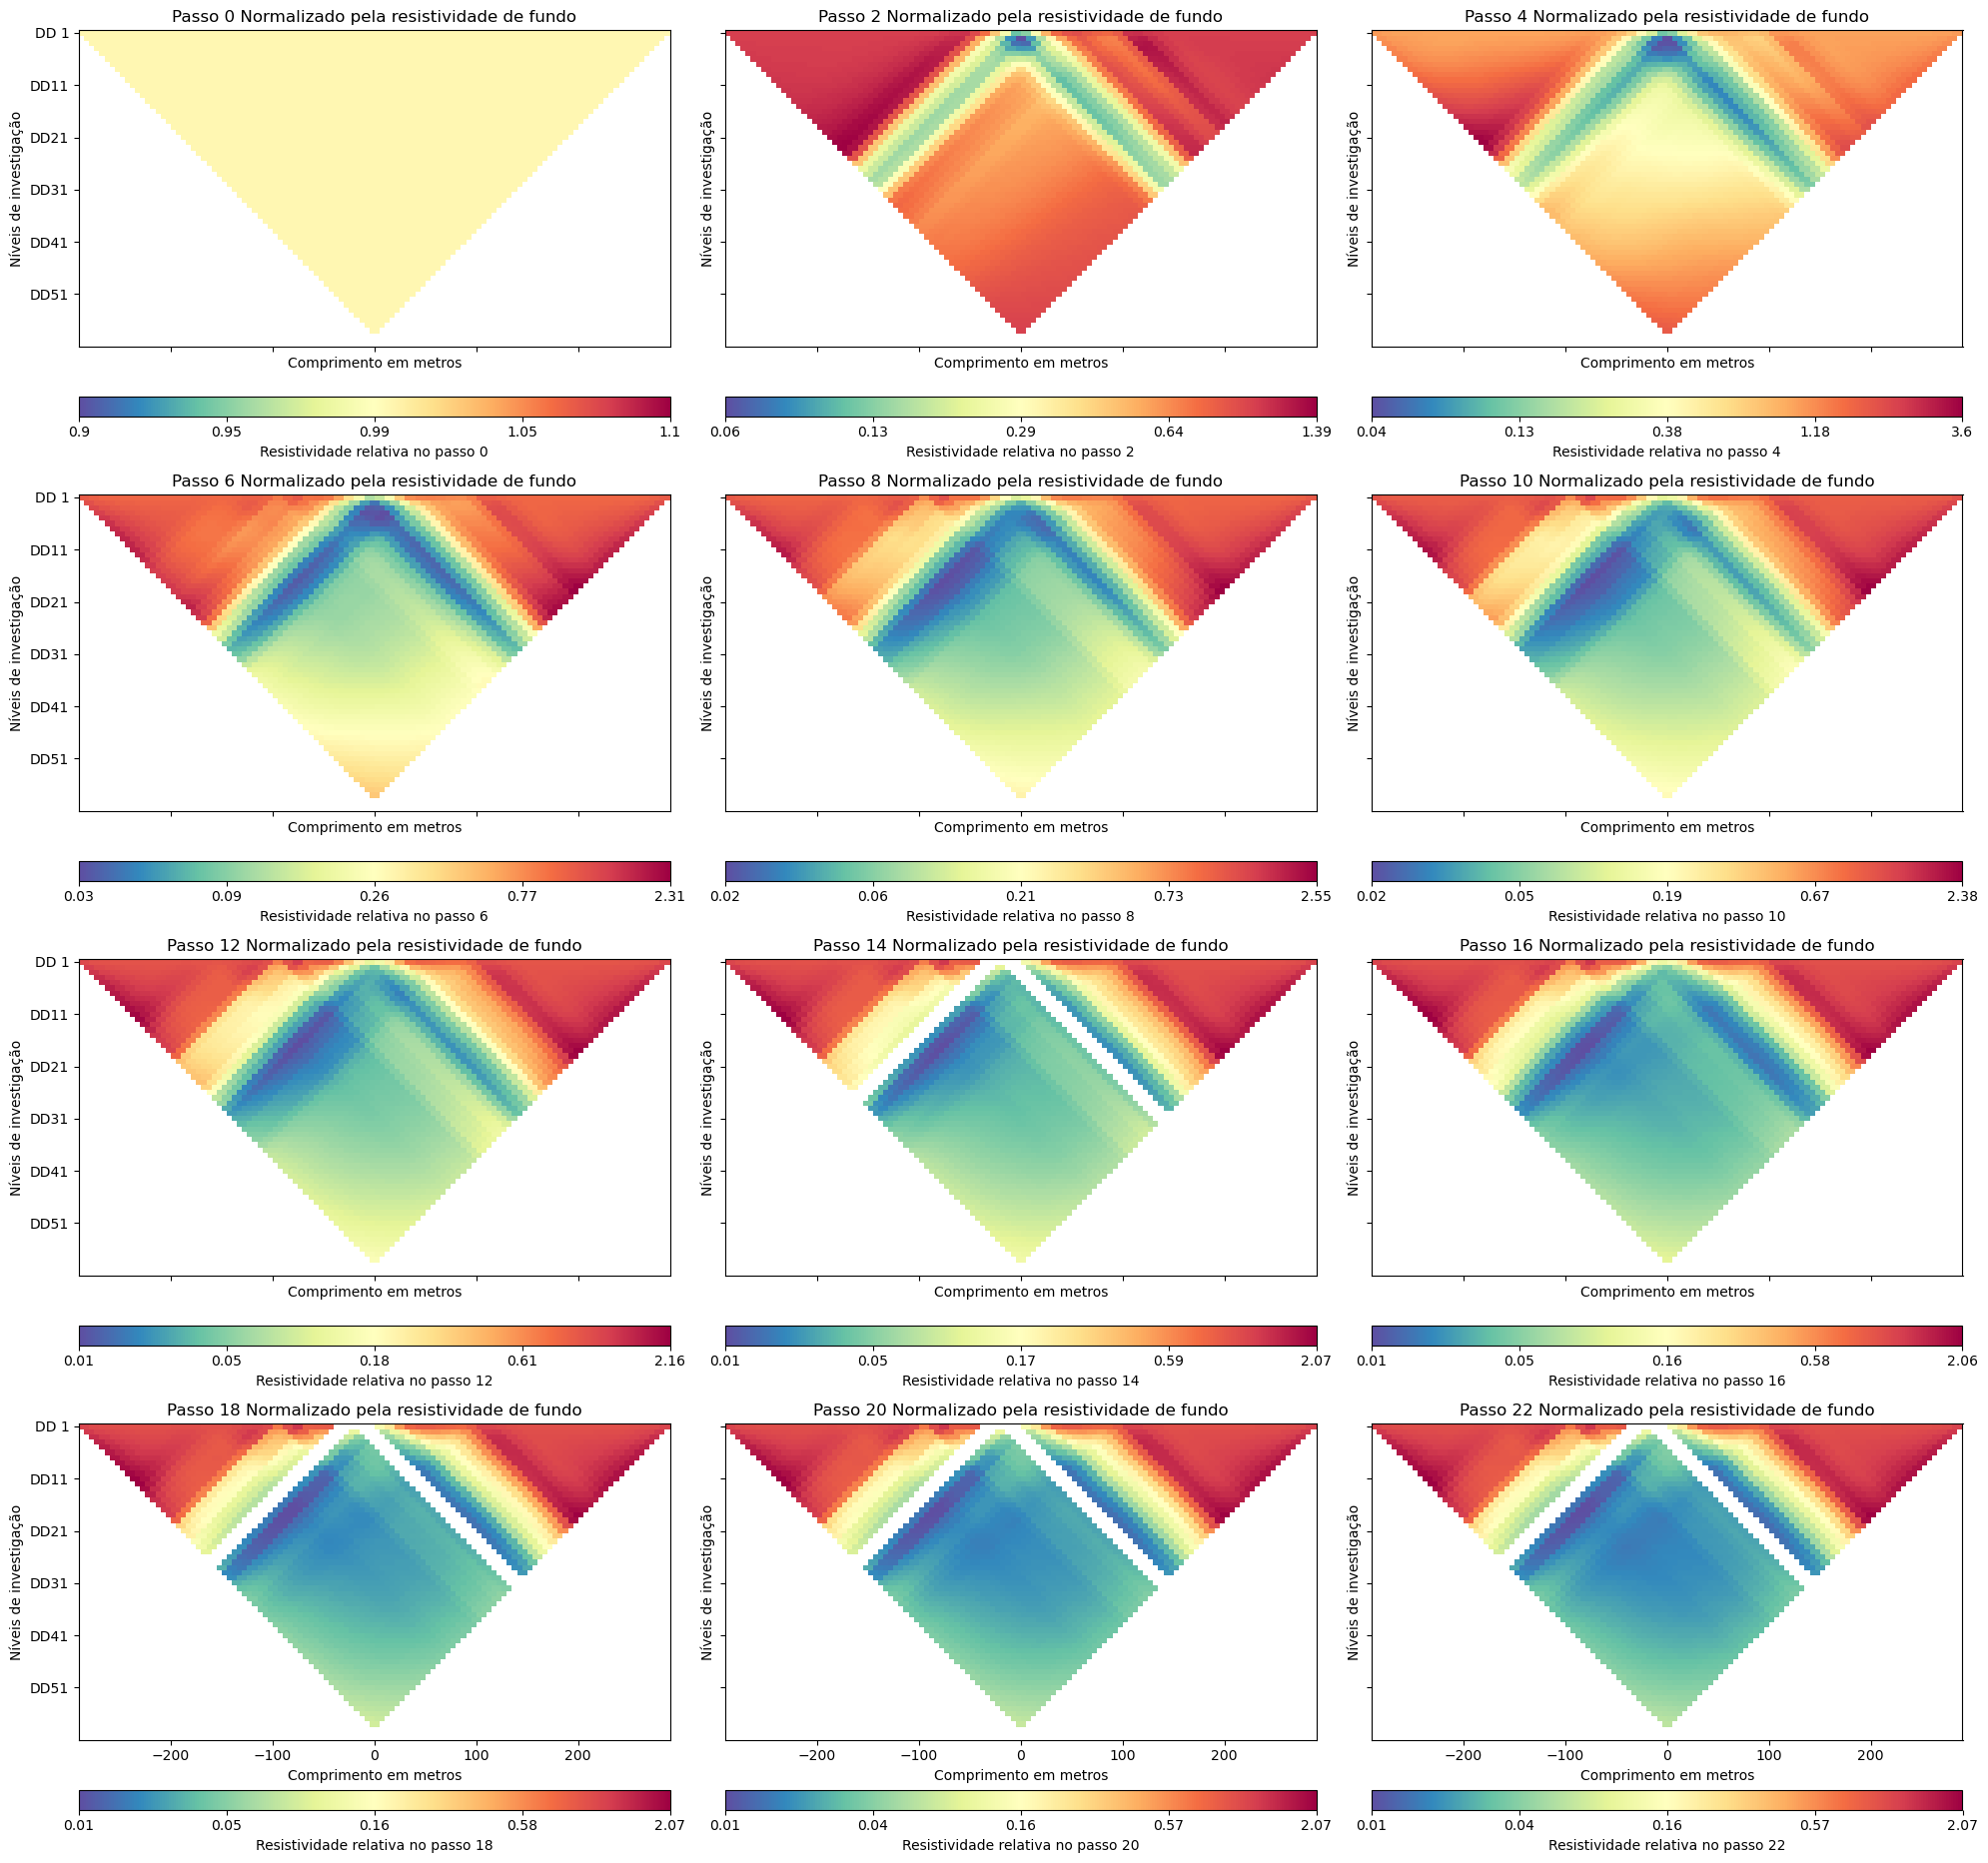

In [24]:
#Visualização denominada pelo Background

fig, axs = plt.subplots(row, col, figsize=(20, 15*((4+1)/(2*njumps))), sharex=True, sharey=True)
for i in range(len(rhoa)):
    
    tempScheme = ertScheme.copy()
    tempScheme.set('rhoa', rhoa[i])
    mean_rhoa = np.mean(rhoa[i])
    std_rhoa = np.std(rhoa[i])
    min_rhoa = np.min(rhoa[i])
    max_rhoa = np.max(rhoa[i])
    Min_calcERT=min_rhoa
    Max_calcERT=max_rhoa
    print(f"Timestep {i}:")
    print(f"Mean: {mean_rhoa}, Std: {std_rhoa}, Min: {min_rhoa}, Max: {max_rhoa}, Min_calcERT: {Min_calcERT}, Max_calcERT: {Max_calcERT},")
    print()
    if i % njumps==0:
        j=i//njumps
        ax=axs[ j// 3, j % 3]
        ax, _ = ERT.showData(tempScheme, vals=rhoa[i]/rhoa[0], LogScale=False,label=f"Resistividade relativa no passo {i}",ax=ax) # Divisão
        ax.set_ylim(y_limit, ax.get_ylim()[1])  
        ax.set_title(f'Passo {i} Normalizado pela resistividade de fundo')
        ax.set_xlabel('Comprimento em metros') 
        ax.set_ylabel('Níveis de investigação') 
plt.tight_layout()
plt.show()

In [ ]:

# Utilização do ERT gerado para realizar inversão
tempScheme.set('rhoa', rhoa[16])  # inversão no passo 15

# Adicionar erros 
#tempScheme.set('err', np.ones(ertScheme.size()) * 0.09)

# Inversão
mgr = ERTManager(data=tempScheme)
mgr.setMesh(meshERT)
mgr.invert()



18/02/25 - 15:37:52 - pyGIMLi - INFO - Found 2 regions.
18/02/25 - 15:37:52 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
18/02/25 - 15:37:54 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/02/25 - 15:38:35 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
18/02/25 - 15:40:43 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 815297 Cells: 1628888 Boundaries: 1222518
18/02/25 - 15:44:12 - pyGIMLi - INFO - Use median(data values)=116.24063942277422
